#### Data Preprocessing

Installing packages


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Loading the dataset

In [2]:
insurance_df = pd.read_csv('../data/insurance.csv')
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# converting the categorical features to numerical values

insurance_df['sex'] = insurance_df['sex'].apply({'male':0, 'female':1}.get)
insurance_df['smoker'] = insurance_df['smoker'].apply({'no':0, 'yes':1}.get)
insurance_df['region'] = insurance_df['region'].apply({'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3}.get)

insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,0,16884.92400
1,18,0,33.770,1,0,1,1725.55230
2,28,0,33.000,3,0,1,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520


Defining features

In [4]:
X = insurance_df.drop('charges', axis=1)
y = insurance_df['charges']

Splitting the data into training and test data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (1070, 6), (1070,)
Test set: (268, 6), (268,)


Defining the metrics

In [6]:
def regression_metrics(true_y, predicted_y):
    mae = mean_absolute_error(true_y, predicted_y)
    mse = mean_squared_error(true_y, predicted_y)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_y, predicted_y)
    return f"MAE: {mae}, \nMSE: {mse}, \nRMSE: {rmse}, \nR2: {r2}"

#### Testing different models (Linear regression, Ridge regression & RandomForestRegressor)

##### Modelling approach

I compared three models to determine which has the lowest error and subsequently to determine which of the models will be better suited to the problem. The models I tried are;
- linear regression model
- ridge regression model
- random forest regressor model

I used MAE (Mean Average Error), RMSE (Root Mean Squared Error), and R2 (R Squared error) as the evaluation metrics. 


1. Linear regression

In [7]:
# creating a linear regression model
lin_reg = LinearRegression()
# Training the model on the training data
lin_reg.fit(X_train, y_train)
# obtaining the coefficients(slope) and the intercept of the linear regression model
print("Slope: ", lin_reg.coef_[0])
print("Intercept: ", lin_reg.intercept_)

Slope:  257.0562636444157
Intercept:  -12779.250821992386


1a. Model Evaluation

In [8]:
# prediction on the test set
pred_y_test_lin = lin_reg.predict(X_test)
print("Performance of the test set:")
print(regression_metrics(y_test, pred_y_test_lin))

Performance of the test set:
MAE: 4186.508898366434, 
MSE: 33635210.431178406, 
RMSE: 5799.587091438356, 
R2: 0.7833463107364539


In [9]:
# compare predictions with actual values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': pred_y_test_lin})
print(comparison_df.head())

           Actual     Predicted
764    9095.06825   8924.407244
887    5272.17580   7116.295018
890   29330.98315  36909.013521
1293   9301.89355   9507.874691
259   33750.29180  27013.350008


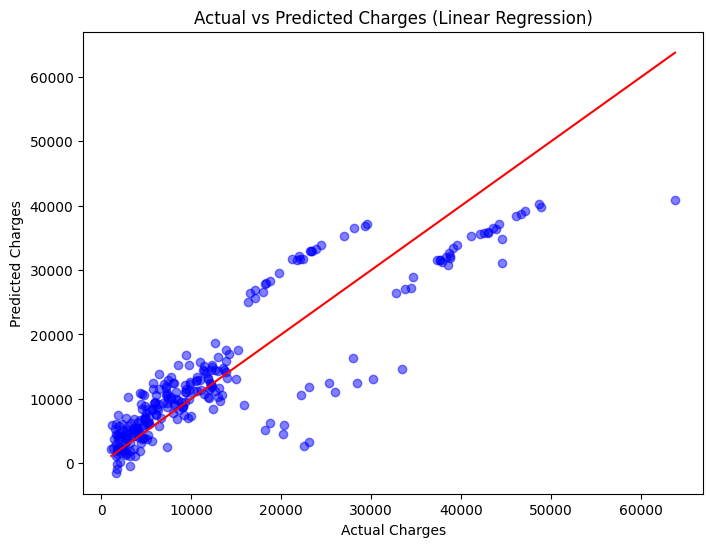

In [10]:
# visualising the results
# plotting predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_y_test_lin, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r-')  # line for perfect predictions
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Linear Regression)')
plt.show()  

2. Ridge regression

In [11]:
ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_train, y_train)

# obtaining the coefficients(slope) and the intercept of the linear regression model
print("Slope: ", ridge_reg.coef_[0])
print("Intercept: ", ridge_reg.intercept_)

Slope:  256.8519140914384
Intercept:  -12740.729998149696


2a. Model evaluation

In [12]:
# prediction on the test set
pred_y_test_ridge = ridge_reg.predict(X_test)
print("Performance of the test set:")
print(regression_metrics(y_test, pred_y_test_ridge))

Performance of the test set:
MAE: 4198.141005321737, 
MSE: 33675792.15420231, 
RMSE: 5803.084710238367, 
R2: 0.7830849126391299


In [13]:
# compare predictions with actual values
comparison_df_ridge = pd.DataFrame({'Actual': y_test, 'Predicted': pred_y_test_ridge})
print(comparison_df_ridge.head())

           Actual     Predicted
764    9095.06825   8947.795021
887    5272.17580   7140.491462
890   29330.98315  36791.840194
1293   9301.89355   9539.062648
259   33750.29180  26913.176556


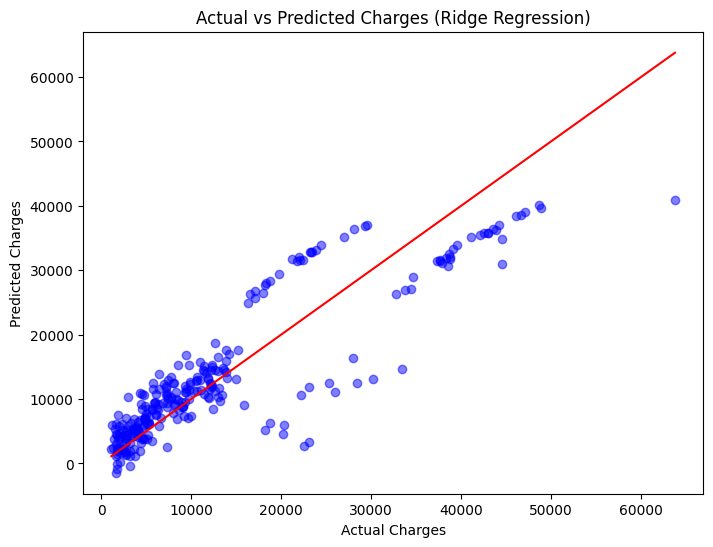

In [14]:
# visualising the results
# plotting predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_y_test_ridge, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r-')  # line for perfect predictions
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Ridge Regression)')
plt.show()

3. Random forest regressor

In [15]:
rf_model = RandomForestRegressor(n_estimators=400, random_state=2)
rf_model.fit(X_train, y_train)
# obtaining the coefficients(slope) and the intercept of the linear regression model
print("Feature Importances: ", rf_model.feature_importances_)

Feature Importances:  [0.13479114 0.0064135  0.21307298 0.02058923 0.61097227 0.01416088]


In [16]:
# prediction on the test set
pred_y_test_rf = rf_model.predict(X_test)
print("Performance of the test set:")
print(regression_metrics(y_test, pred_y_test_rf))

Performance of the test set:
MAE: 2470.9263418573373, 
MSE: 20589063.185028285, 
RMSE: 4537.517293083111, 
R2: 0.8673801519201509


In [17]:
# compare predictions with actual values
comparison_df_rf = pd.DataFrame({'Actual': y_test, 'Predicted': pred_y_test_rf})
print(comparison_df_rf.head())  

           Actual     Predicted
764    9095.06825  10602.516563
887    5272.17580   5108.447530
890   29330.98315  28253.700486
1293   9301.89355  10285.322877
259   33750.29180  34436.080149


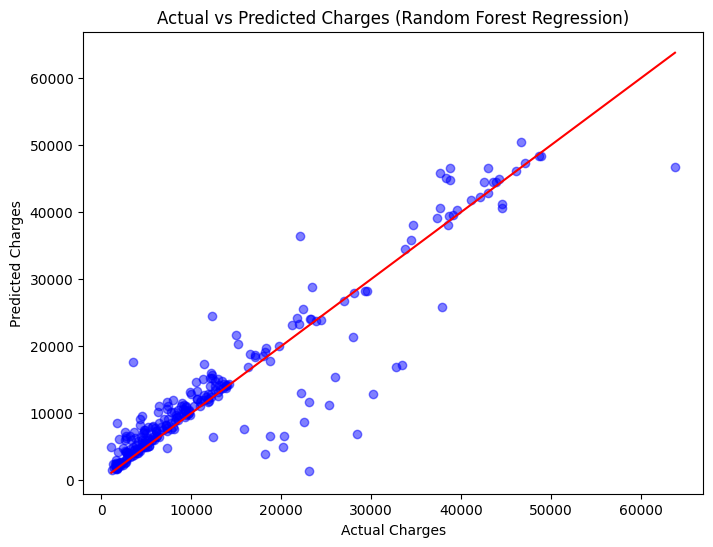

In [18]:
# visualising the results
# plotting predictions vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_y_test_rf, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r-')  # line for perfect predictions
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges (Random Forest Regression)')
plt.show()

#### Summary of all model performances

For the test set

In [19]:
results = []
results.append({
    'model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test, pred_y_test_lin),
    'MSE': mean_squared_error(y_test, pred_y_test_lin),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_y_test_lin)),
    'R2': r2_score(y_test, pred_y_test_lin)
})
results.append({
    'model': 'Ridge Regression',
    'MAE': mean_absolute_error(y_test, pred_y_test_ridge),
    'MSE': mean_squared_error(y_test, pred_y_test_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_y_test_ridge)),
    'R2': r2_score(y_test, pred_y_test_ridge)
})
results.append({
    'model': 'Random Forest Regressor',
    'MAE': mean_absolute_error(y_test, pred_y_test_rf),
    'MSE': mean_squared_error(y_test, pred_y_test_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_y_test_rf)),
    'R2': r2_score(y_test, pred_y_test_rf)
})
pd.DataFrame(results)


,model,MAE,MSE,RMSE,R2
0,Linear Regression,4186.508898,3.363521e+07,5799.587091,0.783346
1,Ridge Regression,4198.141005,3.367579e+07,5803.084710,0.783085
2,Random Forest Regressor,2470.926342,2.058906e+07,4537.517293,0.867380


In [20]:
best = max(results, key=lambda x: x['R2'])
print(f"Best model: {best['model']} with R2 score: {best['R2']}")

Best model: Random Forest Regressor with R2 score: 0.8673801519201509


In [21]:
# map the best model to the actual model object
model_mapping = {
    'Linear Regression': lin_reg,
    'Ridge Regression': ridge_reg,
    'Random Forest Regressor': rf_model
}
best_model = model_mapping[best['model']]
print(f"Best model object: {best_model}")

Best model object: RandomForestRegressor(n_estimators=400, random_state=2)


The random forest regressor is the best of all three models tested because it produced the lowest error. 

#### Building the predictive system

In [22]:
# building a predictive model using the best model to predict insurance costs for existing data
ex_data = pd.DataFrame({
    'age': [28],
    'sex': [0],  # indication of male
    'bmi': [33.0],
    'children': [3],
    'smoker': [0],  # non-smoker
    'region': [1]  # southeast
})
predicted_cost = best_model.predict(ex_data)
print(f"Actual insurance cost for the selected data: {insurance_df.iloc[2]['charges']}")
print(f"Predicted insurance cost for the selected data: {predicted_cost[0]}")
print(f"Prediction accuracy for the selected data: {insurance_df.iloc[2]['charges'] / predicted_cost[0]}")

Actual insurance cost for the selected data: 4449.462
Predicted insurance cost for the selected data: 4867.509770425026
Prediction accuracy for the selected data: 0.9141146520208173
